# SRQ3 — CNN with ViT-Inspired Tokenised Self-Attention

Evaluates whether replacing the linear classifier head with a single Multi-Head Self-Attention (MHSA) layer over ViT-style spatial tokens improves MS classification over the plain linear head baseline.

**Position on the attention complexity spectrum:**
Pure CNN (linear head) → CNN + channel attention (SE) → CNN + channel+spatial attention (CBAM) → CNN + tokenised global self-attention (this) → pure ViT (EfficientFormer)

**Architecture:**
- CNN backbone (base ResNet18, frozen) → 7×7×512 spatial feature map
- Flatten → 49 spatial tokens (ViT tokenisation)
- Linear projection 512→256 + LayerNorm
- Learned positional embeddings (49×256, ViT convention)
- Single MHSA layer (8 heads, dim=256) + residual + LayerNorm
- Global average pool → Linear head

**Architectural note:**
This is not a strict CNN-ViT hybrid — it uses ViT tokenisation (spatial tokens + positional embeddings + self-attention) but replaces the full transformer encoder (multi-block FFN + deep LayerNorm stack) with a single MHSA layer. This is a deliberate design choice: a full DeiT encoder (21M params, 12 blocks) severely overfits on ~1057 training samples. A single MHSA layer adds only ~408K parameters and is the maximum transformer-style complexity justified at this data scale. The architecture is accurately described as a CNN with ViT-inspired tokenised self-attention rather than a full hybrid.

**Trainable components:** token_proj, input_norm, pos_embed, mhsa, post_norm, head (~408K params)
**Backbone:** frozen throughout — same fixed features as SRQ1 base, different aggregation head

**Comparison:** test F1/AUC/ECE vs base standalone (SRQ1 test F1 = 0.9147)

## 1 Paths & Imports

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH     = Path().resolve()
PROJECT_ROOT      = ABSOLUTE_PATH.parents[1]
DATA_DIR          = PROJECT_ROOT / "data" / "raw"
ARCH_EVAL_DIR     = PROJECT_ROOT / "data" / "experiments" / "arch-eval-results"
GRID_SEARCH_DIR   = PROJECT_ROOT / "data" / "experiments" / "grid-search-results"
HEAD_ABLATION_DIR = PROJECT_ROOT / "data" / "experiments" / "head-ablation-results"
RESULTS_DIR       = PROJECT_ROOT / "data" / "experiments" / "cnn-mhsa-hybrid-results"
WEIGHTS_DIR       = RESULTS_DIR / "weights"
CURVES_DIR        = RESULTS_DIR / "training-curves"
PLOTS_DIR         = RESULTS_DIR / "plots"

for d in [RESULTS_DIR, WEIGHTS_DIR, CURVES_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(f"Project root : {PROJECT_ROOT}")
print(f"Results dir  : {RESULTS_DIR}")


Project root : C:\Users\markm\Workspace\ms-machine-learning-diagnosis
Results dir  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\cnn-mhsa-hybrid-results


In [2]:
import csv
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score

import src.scripts.data      as data
import src.scripts.models    as models
import src.scripts.trainer   as trainer
import src.scripts.evaluator as evaluator
import src.scripts.utils     as utils

utils.set_seed(42)


Random seed set to 42 for Python, NumPy, and PyTorch


## 2 Data — Identical Outer Split

Same seed-42 outer 80/20 split as all other experiments. Test set held out until Section 7.

In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories, visualise=False)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels, test_split=0.20, SEED=42
)
print(f"Train+Val: {len(X_trainval)}  |  Test (held out): {len(X_test)}")


get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201
Train+Val: 1321  |  Test (held out): 331


## 3 Configuration

In [4]:
# Load optimal hyperparameters from grid search
OPTIMAL_CONFIG_FILE = GRID_SEARCH_DIR / "optimal_config.csv"
if not OPTIMAL_CONFIG_FILE.exists():
    raise FileNotFoundError(f"optimal_config.csv not found at {OPTIMAL_CONFIG_FILE}")

optimal      = pd.read_csv(OPTIMAL_CONFIG_FILE).iloc[0]
LR_PHASE1    = float(optimal["lr_phase1"])
WD_PHASE1    = float(optimal["wd_phase1"])
LR_PHASE2    = float(optimal["lr_phase2"])
WEIGHT_DECAY = float(optimal["weight_decay"])

OPTIMAL_HEAD_FILE = HEAD_ABLATION_DIR / "optimal_head.csv"
if not OPTIMAL_HEAD_FILE.exists():
    raise FileNotFoundError(f"optimal_head.csv not found at {OPTIMAL_HEAD_FILE}")
WINNING_HEAD = pd.read_csv(OPTIMAL_HEAD_FILE).iloc[0]["head"]

print(f"lr_phase1    = {LR_PHASE1:.0e}")
print(f"wd_phase1    = {WD_PHASE1}")
print(f"lr_phase2    = {LR_PHASE2:.0e}")
print(f"weight_decay = {WEIGHT_DECAY:.0e}")
print(f"winning head = {WINNING_HEAD}")


lr_phase1    = 1e-03
wd_phase1    = 0.0
lr_phase2    = 1e-04
weight_decay = 1e-04
winning head = linear


In [5]:
# Fixed training parameters
N_SPLITS  = 5
BATCH_SIZE = 32
EPOCHS    = 30     # single phase, more budget since backbone is frozen
PATIENCE  = 5      # early stopping on val loss
LR        = 5e-4
SEED      = 42

# Backbone — base ResNet18 
BACKBONE_ARCH = "base"

# Auto-select best val F1 fold weights from arch-eval 
arch_results_file = ARCH_EVAL_DIR / "arch_eval_results.csv"
if not arch_results_file.exists():
    raise FileNotFoundError("arch_eval_results.csv not found — run arch-eval first.")

df_arch      = pd.read_csv(arch_results_file)
df_arch["error"] = df_arch["error"].fillna("")
df_backbone  = (
    df_arch[(df_arch["architecture"] == BACKBONE_ARCH) & (df_arch["error"] == "")]
    .sort_values("val_f1", ascending=False)
)
if df_backbone.empty:
    raise RuntimeError(f"No completed arch-eval runs for {BACKBONE_ARCH}")

BACKBONE_FOLD    = int(df_backbone.iloc[0]["fold"])
BACKBONE_WEIGHTS = utils.weights_path_for(ARCH_EVAL_DIR / "weights", BACKBONE_ARCH, BACKBONE_FOLD)

RESULTS_FILE   = RESULTS_DIR / "hybrid_results.csv"
CSV_FIELDNAMES = [
    "backbone_arch", "backbone_fold", "head",
    "fold", "val_acc", "val_loss", "val_f1",
    "epochs_run", "weights_path", "timestamp", "error"
]
total_runs = N_SPLITS

print(f"Backbone      : {BACKBONE_ARCH}  (arch-eval fold {BACKBONE_FOLD+1}, "
      f"val_f1={df_backbone.iloc[0].val_f1:.4f})")
print(f"Backbone weights : {BACKBONE_WEIGHTS}")
print(f"Head          : {WINNING_HEAD}")
print(f"LR            : {LR:.0e}")
print(f"Epochs        : {EPOCHS}  (patience={PATIENCE})")
print(f"Results       → {RESULTS_FILE}")


Backbone      : base  (arch-eval fold 3, val_f1=0.9423)
Backbone weights : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\weights\base\fold_2.pt
Head          : linear
LR            : 5e-04
Epochs        : 30  (patience=5)
Results       → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\cnn-mhsa-hybrid-results\hybrid_results.csv


## 4 Training Loop — 5-Fold CV

For each fold:
1. Instantiate `CNNMHSAHybrid` and load pre-trained backbone weights (backbone frozen)
2. Train all MHSA components (`mhsa` mode) in a single phase with early stopping

Single phase is sufficient — the two-phase protocol exists in arch-eval to warm up
attention modules before unfreezing the backbone. Here the backbone is always frozen
so there is nothing to stage.

Safe to interrupt and resume — completed folds are skipped.

In [6]:
device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
completed_runs = utils.load_completed_runs(RESULTS_FILE, [("backbone_arch", str), ("fold", int)])
run_number     = len(completed_runs)

print(f"Device : {device}")
print(f"{N_SPLITS} folds — {len(completed_runs)} already completed\n")

run_config = {
    "train": {
        "num_epochs"  : EPOCHS,
        "lr"          : LR,
        "parameters"  : "mhsa",
        "optimiser"   : optim.AdamW,
        "criterion"   : nn.BCEWithLogitsLoss(),
        "weight_decay": WEIGHT_DECAY,
    },
}

for fold_idx in range(N_SPLITS):

    run_key = (BACKBONE_ARCH, fold_idx)
    if run_key in completed_runs:
        print(f"SKIP  fold={fold_idx+1}/{N_SPLITS}")
        continue

    utils.set_seed(SEED)
    run_number += 1
    print(f"\n{'='*65}")
    print(f"  Run {run_number}/{total_runs}  |  fold={fold_idx+1}/{N_SPLITS}")
    print(f"{'='*65}")

    try:
        train_loader, val_loader = data.get_fold_loaders(
            X_trainval, y_trainval, fold_idx=fold_idx,
            train_transform=train_transform, test_transform=test_transform,
            n_splits=N_SPLITS, batch_size=BATCH_SIZE, SEED=SEED
        )

        model = models.get_model(
            architecture="cnn_mhsa_hybrid",
            backbone_arch=BACKBONE_ARCH,
            head=WINNING_HEAD
        )
        model.load_backbone_weights(str(BACKBONE_WEIGHTS), device=device)

        losses, accs, val_losses, val_accs = trainer.train_model(
            model, train_loader, val_loader,
            config_name="train", train_configs=run_config,
            early_stopping_patience=PATIENCE
        )
        epochs_run = len(val_accs)

        utils.plot(
            losses, accs, config_name=f"fold{fold_idx}",
            val_losses=val_losses, val_accuracies=val_accs,
            model_name="cnn_mhsa_hybrid", save_dir=str(CURVES_DIR), show=False
        )

        # Val F1
        model.eval()
        all_preds, all_labels_list = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs   = imgs.to(device)
                logits = model(imgs).squeeze(1)
                preds  = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
                all_preds.extend(preds)
                all_labels_list.extend(lbls.tolist())
        val_f1 = f1_score(all_labels_list, all_preds, average="binary", zero_division=0)

        wpath = utils.weights_path_for(WEIGHTS_DIR, BACKBONE_ARCH, fold_idx)
        utils.save_weights(model, wpath)

        result_row = {
            "backbone_arch" : BACKBONE_ARCH,
            "backbone_fold" : BACKBONE_FOLD,
            "head"          : WINNING_HEAD,
            "fold"          : fold_idx,
            "val_acc"       : round(float(val_accs[-1]),   6),
            "val_loss"      : round(float(val_losses[-1]), 6),
            "val_f1"        : round(float(val_f1),         6),
            "epochs_run"    : epochs_run,
            "weights_path"  : str(wpath),
            "timestamp"     : datetime.now().isoformat(timespec="seconds"),
            "error"         : "",
        }
        utils.append_result(RESULTS_FILE, CSV_FIELDNAMES, result_row)
        completed_runs.add(run_key)

        print(f"  val_f1={val_f1:.4f}  val_acc={val_accs[-1]:.4f}  "
              f"val_loss={val_losses[-1]:.4f}  ({epochs_run}ep)")
        print(f"  Weights → {wpath}")

    except Exception as e:
        error_msg = f"{type(e).__name__}: {str(e)}"
        print(f"ERROR -- {error_msg}")
        traceback.print_exc()
        error_row = {
            "backbone_arch": BACKBONE_ARCH, "backbone_fold": BACKBONE_FOLD,
            "head": WINNING_HEAD, "fold": fold_idx,
            "val_acc": "", "val_loss": "", "val_f1": "",
            "epochs_run": "", "weights_path": "",
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "error": error_msg,
        }
        utils.append_result(RESULTS_FILE, CSV_FIELDNAMES, error_row)

print(f"\n{'='*65}")
print("CNN-MHSA HYBRID TRAINING COMPLETE")
print(f"Results → {RESULTS_FILE}")


Device : cpu
5 folds — 5 already completed

SKIP  fold=1/5
SKIP  fold=2/5
SKIP  fold=3/5
SKIP  fold=4/5
SKIP  fold=5/5

CNN-MHSA HYBRID TRAINING COMPLETE
Results → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\cnn-mhsa-hybrid-results\hybrid_results.csv


## 5 Results Analysis

CV summary — training context only. Definitive results in Section 6.

In [7]:
df_raw = pd.read_csv(RESULTS_FILE)
df_raw["error"] = df_raw["error"].fillna("")
df_ok   = df_raw[df_raw["error"] == ""].copy()
df_fail = df_raw[df_raw["error"] != ""].copy()

for col in ["val_f1", "val_acc", "val_loss"]:
    df_ok[col] = df_ok[col].astype(float)

print(f"Successful runs : {len(df_ok)} / {total_runs}")
print(f"Failed runs     : {len(df_fail)}")
if not df_fail.empty:
    print(df_fail[["fold", "error"]].to_string(index=False))


Successful runs : 5 / 5
Failed runs     : 0


In [8]:
if not df_ok.empty:
    print("CNN-MHSA Hybrid — CV Summary\n")
    print(f"  mean val F1   : {df_ok.val_f1.mean():.4f} ± {df_ok.val_f1.std():.4f}")
    print(f"  mean val acc  : {df_ok.val_acc.mean():.4f} ± {df_ok.val_acc.std():.4f}")
    print(f"  mean val loss : {df_ok.val_loss.mean():.4f} ± {df_ok.val_loss.std():.4f}")
    print()
    print(f"  {'Fold':<6} {'val_f1':>8} {'val_acc':>8} {'val_loss':>10} {'epochs':>7}")
    print(f"  {'-'*44}")
    for _, r in df_ok.sort_values("fold").iterrows():
        print(f"  {int(r.fold)+1:<6} {r.val_f1:>8.4f} {r.val_acc:>8.4f} "
              f"{r.val_loss:>10.4f} {int(r.epochs_run):>7}")

    backbone_cv_f1 = (
        df_arch[(df_arch["architecture"] == BACKBONE_ARCH) & (df_arch["error"] == "")]
        ["val_f1"].mean()
    )
    print(f"\n  Hybrid CV mean F1          : {df_ok.val_f1.mean():.4f}")
    print(f"  {BACKBONE_ARCH} CV mean F1 : {backbone_cv_f1:.4f}")
    print(f"  Δ (hybrid − backbone)      : {df_ok.val_f1.mean() - backbone_cv_f1:+.4f}")


CNN-MHSA Hybrid — CV Summary

  mean val F1   : 0.9803 ± 0.0388
  mean val acc  : 0.9856 ± 0.0280
  mean val loss : 0.0469 ± 0.0814

  Fold     val_f1  val_acc   val_loss  epochs
  --------------------------------------------
  1        0.9952   0.9962     0.0153       6
  2        1.0000   1.0000     0.0052      11
  3        0.9110   0.9356     0.1924       7
  4        1.0000   1.0000     0.0086      13
  5        0.9952   0.9962     0.0127      11

  Hybrid CV mean F1          : 0.9803
  base CV mean F1 : 0.9174
  Δ (hybrid − backbone)      : +0.0629


## 6 Final Test Set Evaluation — SRQ3

Auto-selects best val F1 fold, evaluates once on the held-out test set.

**Note on CV validity:** Several folds achieved val F1 ≈ 1.0 from epoch 1. This reflects the high separability of frozen base backbone features in certain validation splits, not model quality. The CV summary is reported for completeness but the test result is the definitive evaluation.

In [9]:
if df_ok.empty:
    raise RuntimeError("No completed folds — run Section 4 first.")

best_row  = df_ok.sort_values("val_f1", ascending=False).iloc[0]
BEST_FOLD = int(best_row["fold"])
print(f"Selected fold {BEST_FOLD+1}  "
      f"(val_f1={best_row.val_f1:.4f}  val_loss={best_row.val_loss:.4f})")


Selected fold 2  (val_f1=1.0000  val_loss=0.0052)


In [10]:
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loader = data.get_test_loader(X_test, y_test, test_transform, BATCH_SIZE)
print(f"Device: {device}")


get_test_loader()>>> Test loader ready — 331 samples
Device: cpu


In [11]:
wpath = utils.weights_path_for(WEIGHTS_DIR, BACKBONE_ARCH, BEST_FOLD)

utils.set_seed(SEED)
model = models.get_model(
    architecture="cnn_mhsa_hybrid",
    backbone_arch=BACKBONE_ARCH,
    head=WINNING_HEAD
)
model = utils.load_weights(model, wpath, device=device)

print(f"\n{'='*60}")
print(f"  CNN-MHSA Hybrid  (backbone={BACKBONE_ARCH}  fold {BEST_FOLD+1})")
print(f"{'='*60}")

acc, prec, rec, f1, auc, ece, conf, report = evaluator.evaluate_model(
    model=model, test_loader=test_loader, device=device
)

# Comparison against SRQ1 standalone
arch_test_file = ARCH_EVAL_DIR / "arch_eval_test_results.csv"
if arch_test_file.exists():
    df_srq1 = pd.read_csv(arch_test_file, index_col="architecture")
    if BACKBONE_ARCH in df_srq1.index:
        sf1  = float(df_srq1.loc[BACKBONE_ARCH, "test_f1"])
        sauc = float(df_srq1.loc[BACKBONE_ARCH, "test_auc"])
        sece = float(df_srq1.loc[BACKBONE_ARCH, "test_ece"])
        print(f"\nSRQ3 Comparison:")
        print(f"  {'':32} {'F1':>8} {'AUC':>8} {'ECE':>8}")
        print(f"  {'-'*58}")
        print(f"  {'CNN-MHSA Hybrid':<32} {f1:>8.4f} {auc:>8.4f} {ece:>8.4f}")
        print(f"  {BACKBONE_ARCH+' (standalone)':<32} {sf1:>8.4f} {sauc:>8.4f} {sece:>8.4f}")
        print(f"  {'Δ (hybrid − standalone)':<32} {f1-sf1:>+8.4f} "
              f"{auc-sauc:>+8.4f} {ece-sece:>+8.4f}")


Random seed set to 42 for Python, NumPy, and PyTorch
get_model()>>> architecture='base'  head='linear'
CNNMHSAHybrid >>> backbone='base'  head='linear'
  Total params     : 11,585,346
  Trainable        : 11,585,346  (100%)
  ├─ CNN backbone  : 11,177,025  (frozen after load_backbone_weights)
  ├─ token_proj    : 131,328
  ├─ input_norm    : 512
  ├─ pos_embed     : 12,544
  ├─ mhsa          : 263,168
  ├─ post_norm     : 512
  └─ head          : 257
get_model()>>> architecture='cnn_mhsa_hybrid'  backbone_arch='base'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.

  CNN-MHSA Hybrid  (backbone=base  fold 2)
Accuracy  : 0.9305
Precision : 0.8963
Recall    : 0.9308
F1        : 0.9132
AUC-ROC   : 0.9870
ECE       : 0.0547  (lower = better calibrated; 0 = perfect)
Confusion Matrix:
 [[187  14]
 [  9 121]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       201
           1   

In [12]:
TEST_RESULTS_FILE = RESULTS_DIR / "hybrid_test_results.csv"

test_row = {
    "backbone_arch" : BACKBONE_ARCH,
    "selected_fold" : BEST_FOLD,
    "test_f1"       : round(f1,   4),
    "test_auc"      : round(auc,  4),
    "test_ece"      : round(ece,  4),
    "test_acc"      : round(acc,  4),
    "test_prec"     : round(prec, 4),
    "test_rec"      : round(rec,  4),
    "conf_matrix"   : conf.tolist(),
}
pd.DataFrame([test_row]).to_csv(TEST_RESULTS_FILE, index=False)
print(f"Test results saved → {TEST_RESULTS_FILE}")


Test results saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\cnn-mhsa-hybrid-results\hybrid_test_results.csv


save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\cnn-mhsa-hybrid-results\plots\srq3_test_results.svg


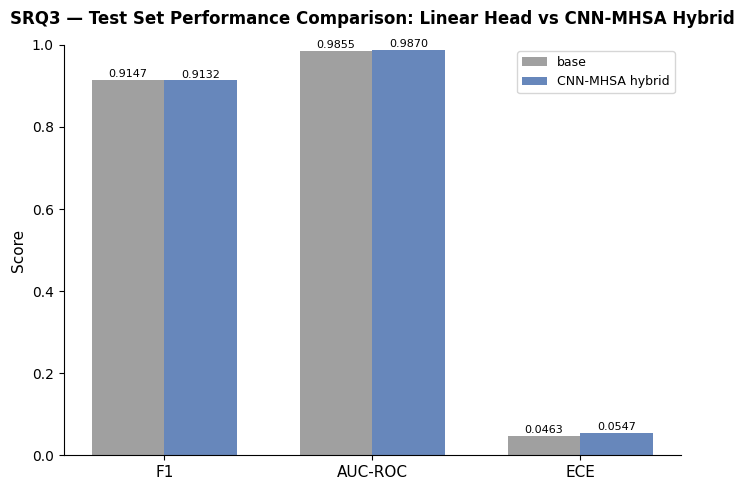

In [13]:
# Visualisation
if arch_test_file.exists() and BACKBONE_ARCH in df_srq1.index:
    metrics         = ["F1", "AUC-ROC", "ECE"]
    hybrid_vals     = [f1,  auc,  ece]
    standalone_vals = [sf1, sauc, sece]
    x, w            = np.arange(len(metrics)), 0.35

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(x - w/2, standalone_vals, w, label=f"{BACKBONE_ARCH}",
           color="#888", alpha=0.80)
    ax.bar(x + w/2, hybrid_vals, w, label="CNN-MHSA hybrid",
           color="#4C72B0", alpha=0.85)
    for xi, (sv, hv) in enumerate(zip(standalone_vals, hybrid_vals)):
        ax.text(xi - w/2, sv + 0.002, f"{sv:.4f}", ha="center", va="bottom", fontsize=8)
        ax.text(xi + w/2, hv + 0.002, f"{hv:.4f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title("SRQ3 — Test Set Performance Comparison: Linear Head vs CNN-MHSA Hybrid",
             fontsize=12, fontweight="bold", pad=15)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    all_vals = hybrid_vals + standalone_vals
    pad = (max(all_vals) - min(all_vals)) * 0.3 or 0.02
    ax.set_ylim(max(0, min(all_vals) - pad), min(1, max(all_vals) + pad))

    plt.tight_layout()
    utils.save_fig(fig, PLOTS_DIR, "srq3_test_results", formats=("svg",))
    plt.show()